In [1]:
import sys
import os

project_root = os.path.abspath("../")
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import pandas as pd
from data_mining import Dataset
from sklearn.model_selection import train_test_split
from damavand.damavand.signal_processing.transformations import fft
from damavand.damavand.utils import z_score_scaler
from ae import WideConvAutoencoder
from torchinfo import summary
import torch
from utils import plot_error_distribution
import numpy as np

In [3]:
dataset = Dataset(operations=["05"])
data = dataset.mine(win_len=1000, hop_len=1000)

/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP05/bad/M01_Aug_2019_OP05_000.h5  ---  (26793, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP05/bad/M01_Feb_2019_OP05_000.h5  ---  (29831, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP05/bad/M01_Feb_2019_OP05_001.h5  ---  (29621, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP05/bad/M01_Feb_2021_OP05_000.h5  ---  (30000, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP05/good/M01_Aug_2019_OP05_000.h5  ---  (46080, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP05/good/M01_Aug_2019_OP05_001.h5  ---  (41984, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP05/good/M01_Aug_2019_OP05_002.h5  ---  (47104, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/data/M01/OP05/good/M01_Aug_2019_OP05_003.h5  ---  (43008, 3)
/nfs/home/amiber/ml_for_pdm_course_project/CNC_Machining/dat

In [4]:
df = pd.concat(data["OP05"]["0"])
df

,0,1,2,3,4,5,6,7,8,9,...,994,995,996,997,998,999,machine,operation,state,file
0,-9.0,-50.0,-48.0,11.0,17.0,-11.0,-1.0,9.0,19.0,-29.0,...,33.0,37.0,40.0,33.0,19.0,21.0,M01,OP05,bad,M01_Aug_2019_OP05_000.h5
1,-3.0,27.0,-27.0,-39.0,7.0,9.0,54.0,33.0,23.0,-35.0,...,1188.0,1073.0,1138.0,897.0,1128.0,839.0,M01,OP05,bad,M01_Aug_2019_OP05_000.h5
2,1007.0,630.0,942.0,595.0,897.0,616.0,650.0,528.0,638.0,452.0,...,439.0,610.0,616.0,757.0,550.0,718.0,M01,OP05,bad,M01_Aug_2019_OP05_000.h5
3,519.0,573.0,368.0,435.0,203.0,199.0,187.0,54.0,11.0,-97.0,...,95.0,48.0,-39.0,-91.0,-27.0,-58.0,M01,OP05,bad,M01_Aug_2019_OP05_000.h5
4,35.0,99.0,-17.0,33.0,37.0,3.0,-52.0,-48.0,-33.0,-5.0,...,11.0,1.0,-23.0,15.0,25.0,29.0,M01,OP05,bad,M01_Aug_2019_OP05_000.h5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42,-7.0,-25.0,13.0,-37.0,5.0,-11.0,-5.0,-21.0,0.0,-15.0,...,-15.0,-17.0,-13.0,-15.0,-9.0,-11.0,M01,OP05,good,M01_Feb_2021_OP05_008.h5
43,-15.0,-17.0,-7.0,-13.0,-13.0,-21.0,-11.0,-3.0,-5.0,-15.0,...,-11.0,-5.0,-37.0,-7.0,-27.0,-7.0,M01,OP05,good,M01_Feb_2021_OP05_008.h5
44,-7.0,-31.0,-13.0,-33.0,-17.0,-31.0,-3.0,-44.0,-7.0,-21.0,...,-21.0,-13.0,-11.0,-21.0,-17.0,-15.0,M01,OP05,good,M01_Feb_2021_OP05_008.h5
45,-17.0,-7.0,-17.0,-5.0,-15.0,-5.0,-15.0,-15.0,-19.0,-15.0,...,-13.0,-5.0,-21.0,-19.0,0.0,-29.0,M01,OP05,good,M01_Feb_2021_OP05_008.h5


In [5]:
df_train, df_test = train_test_split(df, test_size=0.4)
x_train, y_train = df_train.iloc[:, : -4], df_train.iloc[:, -4 :]
x_test, y_test = df_test.iloc[:, :-4], df_test.iloc[:, -4:]

In [6]:
x_train_fft = fft(x_train)
x_test_fft = fft(x_test)

x_train_fft_scaled, x_test_fft_scaled = z_score_scaler(x_train_fft), z_score_scaler(x_test_fft)
print(x_train_fft_scaled.shape, x_test_fft_scaled.shape)

(931, 500) (622, 500)


In [7]:
x_train_fft_scaled, x_test_fft_scaled = (
    x_train_fft_scaled.to_numpy().reshape(-1, 1, 500),
    x_test_fft_scaled.to_numpy().reshape(-1, 1, 500),
)

In [8]:
ae = WideConvAutoencoder(input_channels=1)
summary(ae, input_size=(1, 1, 500))

Layer (type:depth-idx)                   Output Shape              Param #
WideConvAutoencoder                      [1, 1, 1000]              --
├─Sequential: 1-1                        [1, 30, 32]               --
│    └─Conv1d: 2-1                       [1, 30, 100]              780
│    └─ReLU: 2-2                         [1, 30, 100]              --
│    └─AdaptiveMaxPool1d: 2-3            [1, 30, 32]               --
├─Sequential: 1-2                        [1, 50]                   --
│    └─Flatten: 2-4                      [1, 960]                  --
│    └─Linear: 2-5                       [1, 50]                   48,050
├─Linear: 1-3                            [1, 960]                  48,960
├─Sequential: 1-4                        [1, 1, 1000]              --
│    └─Unflatten: 2-6                    [1, 30, 32]               --
│    └─Upsample: 2-7                     [1, 30, 200]              --
│    └─ConvTranspose1d: 2-8              [1, 1, 1000]              751
Total

In [9]:
y_train["state"].value_counts()

state
good    854
bad      77
Name: count, dtype: int64

In [10]:
y_test["state"].value_counts()

state
good    585
bad      37
Name: count, dtype: int64

In [11]:
ae.fit(
    torch.tensor(x_train_fft_scaled).float()[
        y_train[y_train["state"] == "good"].index, :, :
    ],
    epochs=500,
    batch_size=16,
    lr=1e-3,
    val_split=0.2,
)

Epoch 10/500 | Train: 0.099481 | Val: 0.090238
Epoch 20/500 | Train: 0.073462 | Val: 0.068129
Epoch 30/500 | Train: 0.064640 | Val: 0.060185
Epoch 40/500 | Train: 0.059990 | Val: 0.055518
Epoch 50/500 | Train: 0.058524 | Val: 0.054360
Epoch 60/500 | Train: 0.056347 | Val: 0.051880
Epoch 70/500 | Train: 0.055258 | Val: 0.050643
Epoch 80/500 | Train: 0.054475 | Val: 0.049890
Epoch 90/500 | Train: 0.054888 | Val: 0.050707
Epoch 100/500 | Train: 0.053426 | Val: 0.048876
Epoch 110/500 | Train: 0.054548 | Val: 0.048448
Epoch 120/500 | Train: 0.052825 | Val: 0.047895
Epoch 130/500 | Train: 0.054740 | Val: 0.049874
Epoch 140/500 | Train: 0.053121 | Val: 0.047607
Epoch 150/500 | Train: 0.052243 | Val: 0.047176
Epoch 160/500 | Train: 0.052364 | Val: 0.047198
Epoch 170/500 | Train: 0.053339 | Val: 0.047411
Epoch 180/500 | Train: 0.052137 | Val: 0.047137
Epoch 190/500 | Train: 0.052476 | Val: 0.047576
Epoch 200/500 | Train: 0.052032 | Val: 0.046783
Epoch 210/500 | Train: 0.052115 | Val: 0.046795
E

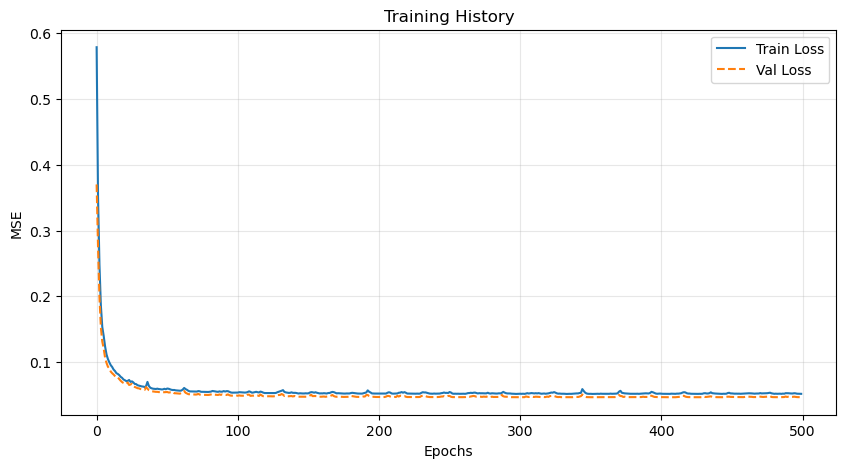

In [12]:
ae.plot_history()

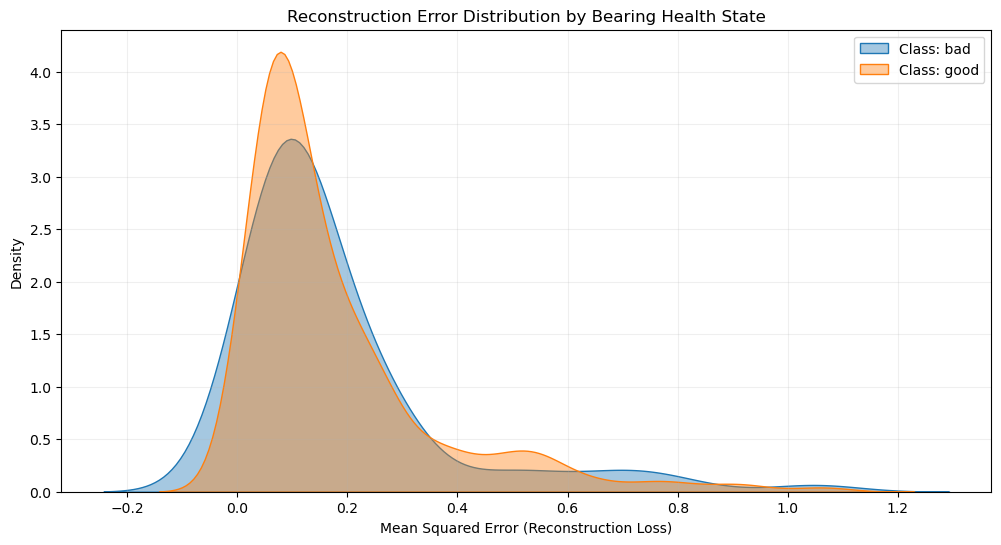

In [13]:
plot_error_distribution(ae, torch.tensor(x_train_fft_scaled).float(), y_train["state"])

In [14]:
train_rec_errs = ae.get_reconstruction_errors(torch.tensor(x_train_fft_scaled).float())
test_rec_errs = ae.get_reconstruction_errors(torch.tensor(x_test_fft_scaled).float())

In [15]:
treshold = np.percentile(train_rec_errs, 95)
print(f"Threshold: {treshold}")

Threshold: 0.5604900121688843


In [16]:
flags = np.where(test_rec_errs > treshold, "bad", "good").tolist()
flags

['good',
 'good',
 'good',
 'good',
 'good',
 'bad',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'bad',
 'good',
 'bad',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'bad',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'bad',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'bad',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good',
 'good'

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test["state"], flags))

              precision    recall  f1-score   support

         bad       0.02      0.03      0.03        37
        good       0.94      0.93      0.93       585

    accuracy                           0.88       622
   macro avg       0.48      0.48      0.48       622
weighted avg       0.88      0.88      0.88       622



In [18]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test["state"], flags)

array([[  1,  36],
       [ 41, 544]])